In [37]:
from pathlib import Path
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt

In [38]:
DATA_DIR = Path("../data")

TRAIN_DIR = DATA_DIR / "Training_set"
VAL_DIR = DATA_DIR / "Validation_set"
TEST_DIR = DATA_DIR / "Test_set"

TRAIN_DIR

WindowsPath('../data/Training_set')

In [39]:
train_images = [
    p for p in TRAIN_DIR.iterdir()
    if p.suffix.lower() in [".jpg", ".jpeg", ".png"]
]

train_csv = list(TRAIN_DIR.glob("*.csv"))

print("Training images:", len(train_images))
print("Training CSV:", [p.name for p in train_csv])

Training images: 509
Training CSV: ['RFMiD_2_Training_labels.csv']


In [40]:
train_labels = pd.read_csv(
    train_csv[0],
    encoding="latin1"
)

train_labels.head()

,ID,WNL,AH,AION,ARMD,BRVO,CB,CF,CL,CME,...,RT,SOFE,ST,TD,TSLN,TV,VS,HTN,IIH,Unnamed: 52
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,NaN
1,2,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,NaN
2,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,NaN
3,4,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,NaN
4,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,NaN


In [41]:
train_labels.columns.tolist()

['ID',
 'WNL',
 'AH',
 'AION',
 'ARMD',
 'BRVO',
 'CB',
 'CF',
 'CL',
 'CME',
 'CNV',
 'CRAO',
 'CRS',
 'CRVO',
 'CSR',
 'CWS',
 'CSC',
 'DN',
 'DR',
 'EDN',
 'ERM',
 'GRT',
 'HPED',
 'HR',
 'LS',
 'MCA',
 'ME',
 'MH',
 'MHL',
 'MS',
 'MYA',
 'ODC',
 'ODE',
 'ODP',
 'ON\xa0',
 'OPDM',
 'PRH',
 'RD',
 'RHL',
 'RTR',
 'RP',
 'RPEC',
 'RS',
 'RT',
 'SOFE',
 'ST',
 'TD',
 'TSLN',
 'TV',
 'VS',
 'HTN',
 'IIH',
 'Unnamed: 52']

In [42]:
train_labels.columns = train_labels.columns.str.strip()

train_labels = train_labels.loc[
    :,
    ~train_labels.columns.str.startswith("Unnamed")
]

train_labels.columns.tolist()

['ID',
 'WNL',
 'AH',
 'AION',
 'ARMD',
 'BRVO',
 'CB',
 'CF',
 'CL',
 'CME',
 'CNV',
 'CRAO',
 'CRS',
 'CRVO',
 'CSR',
 'CWS',
 'CSC',
 'DN',
 'DR',
 'EDN',
 'ERM',
 'GRT',
 'HPED',
 'HR',
 'LS',
 'MCA',
 'ME',
 'MH',
 'MHL',
 'MS',
 'MYA',
 'ODC',
 'ODE',
 'ODP',
 'ON',
 'OPDM',
 'PRH',
 'RD',
 'RHL',
 'RTR',
 'RP',
 'RPEC',
 'RS',
 'RT',
 'SOFE',
 'ST',
 'TD',
 'TSLN',
 'TV',
 'VS',
 'HTN',
 'IIH']

In [43]:
print("DR distribution:")
print(train_labels["DR"].value_counts())

print("\nWNL distribution:")
print(train_labels["WNL"].value_counts())

DR distribution:
DR
0    467
1     42
Name: count, dtype: int64

WNL distribution:
WNL
0    352
1    157
Name: count, dtype: int64


In [44]:
image_ids = {p.stem for p in train_images}
label_ids = set(train_labels["ID"].astype(str))

missing_labels = image_ids - label_ids
missing_images = label_ids - image_ids

print("Images without labels:", len(missing_labels))
print("Labels without images:", len(missing_images))

print("\nImage IDs without labels:")
print(sorted(missing_labels))

print("\nLabel IDs without images:")
print(sorted(missing_images))

Images without labels: 2
Labels without images: 2

Image IDs without labels:
['222', '79']

Label IDs without images:
['216', '89']


In [45]:
# Create a dataframe containing only images that have matching labels

train_df = train_labels[
    train_labels["ID"].astype(str).isin(image_ids)
].copy()

# Keep only the information we need for now
train_df = train_df[["ID", "WNL", "DR"]]

# Add the corresponding image path
train_df["image_path"] = train_df["ID"].astype(str).apply(
    lambda x: next(
        p for p in train_images
        if p.stem == x
    )
)

train_df.head()

,ID,WNL,DR,image_path
0,1,0,0,..\data\Training_set\1.jpg
1,2,0,0,..\data\Training_set\2.jpg
2,3,0,0,..\data\Training_set\3.jpg
3,4,0,0,..\data\Training_set\4.jpg
4,5,0,0,..\data\Training_set\5.jpg


In [46]:
# Cross-tabulation of DR and WNL
pd.crosstab(
    train_df["DR"],
    train_df["WNL"],
    margins=True
)

WNL,0,1,All
DR,,,
0,309,156,465
1,42,0,42
All,351,156,507


In [47]:
label_columns = [c for c in train_labels.columns if c != "ID"]

label_summary = pd.DataFrame({
    "label": label_columns,
    "count": [train_labels[c].sum() for c in label_columns]
})

label_summary["percentage"] = (
    label_summary["count"] / len(train_labels) * 100
)

label_summary = label_summary.sort_values(
    "count",
    ascending=False
)

label_summary

,label,count,percentage
0,WNL,157,30.844794
22,HR,57,11.198428
17,DR,42,8.251473
18,EDN,36,7.072692
29,MYA,27,5.304519
26,MH,26,5.108055
11,CRS,25,4.911591
42,RT,24,4.715128
8,CME,23,4.518664
30,ODC,21,4.125737


In [48]:
binary_summary = pd.DataFrame({
    "group": [
        "DR",
        "Normal (WNL)"
    ],
    "count": [
        ((train_df["DR"] == 1)).sum(),
        ((train_df["DR"] == 0) & (train_df["WNL"] == 1)).sum()
    ]
})

binary_summary["percentage"] = (
    binary_summary["count"] / binary_summary["count"].sum() * 100
)

binary_summary

,group,count,percentage
0,DR,42,21.212121
1,Normal (WNL),156,78.787879


In [49]:
image_sizes = []

for path in train_images:
    try:
        with Image.open(path) as img:
            image_sizes.append({
                "image_id": path.stem,
                "width": img.width,
                "height": img.height,
                "mode": img.mode,
                "format": img.format
            })
    except Exception as e:
        print(f"Could not read {path.name}: {e}")

image_info = pd.DataFrame(image_sizes)

image_info.head()

,image_id,width,height,mode,format
0,1,512,512,RGB,JPEG
1,10,512,512,RGB,JPEG
2,100,512,512,RGB,JPEG
3,101,512,512,RGB,JPEG
4,102,512,512,RGB,JPEG


In [50]:
image_info[["width", "height"]].describe()

,width,height
count,509.000000,509.000000
mean,1047.889980,851.552063
std,694.092499,453.969738
min,512.000000,512.000000
25%,512.000000,512.000000
50%,512.000000,512.000000
75%,2048.000000,1536.000000
max,2048.000000,1536.000000


In [51]:
resolution_counts = (
    image_info
    .groupby(["width", "height"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)

resolution_counts

,width,height,count
0,512,512,313
2,2048,1536,144
1,1504,1000,52


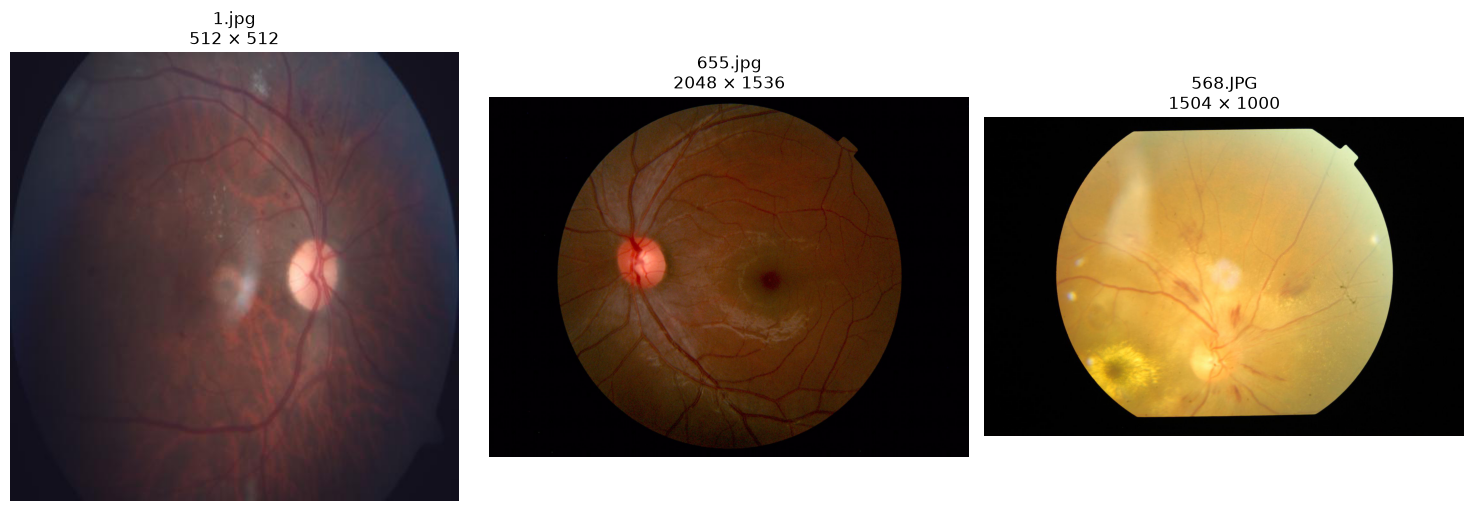

In [52]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (width, height) in zip(
    axes,
    resolution_counts[["width", "height"]].itertuples(index=False)
):
    sample_path = next(
        p for p in train_images
        if Image.open(p).size == (width, height)
    )

    img = Image.open(sample_path)

    ax.imshow(img)
    ax.set_title(f"{sample_path.name}\n{width} × {height}")
    ax.axis("off")

plt.tight_layout()
plt.show()

In [53]:
binary_df = train_df[
    (train_df["DR"] == 1) |
    ((train_df["DR"] == 0) & (train_df["WNL"] == 1))
].copy()

binary_df["target"] = binary_df["DR"]

print("Total binary images:", len(binary_df))
print("\nClass distribution:")
print(binary_df["target"].value_counts())

Total binary images: 198

Class distribution:
target
0    156
1     42
Name: count, dtype: int64


In [55]:
# Select the disease/finding labels
label_columns = [
    c for c in train_labels.columns
    if c != "ID"
]

# Calculate pairwise correlation between binary labels
label_corr = train_labels[label_columns].corr()

label_corr.round(2)

,WNL,AH,AION,ARMD,BRVO,CB,CF,CL,CME,CNV,...,RS,RT,SOFE,ST,TD,TSLN,TV,VS,HTN,IIH
WNL,1.00,-0.03,-0.04,-0.07,-0.10,-0.04,-0.05,-0.05,-0.15,-0.03,...,-0.07,-0.15,-0.04,-0.04,-0.09,-0.14,-0.09,-0.06,-0.08,-0.05
AH,-0.03,1.00,-0.00,-0.00,-0.01,-0.00,-0.00,-0.00,-0.01,-0.00,...,-0.00,-0.01,-0.00,-0.00,-0.01,-0.01,-0.01,-0.00,-0.01,-0.00
AION,-0.04,-0.00,1.00,-0.01,-0.01,-0.00,-0.00,-0.00,-0.01,-0.00,...,-0.01,-0.01,-0.00,-0.00,-0.01,-0.01,-0.01,-0.01,-0.01,-0.00
ARMD,-0.07,-0.00,-0.01,1.00,-0.02,-0.01,-0.01,-0.01,-0.02,-0.00,...,-0.01,0.07,-0.01,-0.01,-0.01,-0.02,-0.01,-0.01,-0.01,-0.01
BRVO,-0.10,-0.01,-0.01,-0.02,1.00,-0.01,-0.01,-0.01,-0.03,-0.01,...,-0.02,-0.03,-0.01,-0.01,-0.02,-0.03,-0.02,-0.01,-0.02,-0.01
CB,-0.04,-0.00,-0.00,-0.01,-0.01,1.00,-0.00,-0.00,-0.01,-0.00,...,-0.01,-0.01,-0.00,-0.00,-0.01,-0.01,-0.01,-0.01,-0.01,-0.00
CF,-0.05,-0.00,-0.00,-0.01,-0.01,-0.00,1.00,-0.01,-0.02,-0.00,...,-0.01,-0.02,-0.00,-0.00,-0.01,-0.02,-0.01,-0.01,-0.01,-0.01
CL,-0.05,-0.00,-0.00,-0.01,-0.01,-0.00,-0.01,1.00,-0.02,-0.00,...,-0.01,0.10,-0.00,-0.00,-0.01,-0.02,-0.01,-0.01,-0.01,-0.01
CME,-0.15,-0.01,-0.01,-0.02,-0.03,-0.01,-0.02,-0.02,1.00,-0.01,...,-0.02,0.04,-0.01,-0.01,-0.03,-0.04,-0.03,-0.02,-0.03,-0.02
CNV,-0.03,-0.00,-0.00,-0.00,-0.01,-0.00,-0.00,-0.00,-0.01,1.00,...,-0.00,-0.01,-0.00,-0.00,-0.01,-0.01,-0.01,-0.00,-0.01,-0.00


In [56]:
dr_correlations = (
    label_corr["DR"]
    .drop("DR")
    .sort_values(ascending=False)
)

dr_correlations

RTR    -0.013306
HPED   -0.013306
GRT    -0.013306
CRAO   -0.013306
RHL    -0.013306
AH     -0.013306
ME     -0.013306
ON     -0.013306
CNV    -0.013306
CSC    -0.013306
OPDM   -0.013306
RPEC   -0.018836
RP     -0.018836
SOFE   -0.018836
AION   -0.018836
ST     -0.018836
CB     -0.018836
CF     -0.023091
CL     -0.023091
IIH    -0.023091
ERM    -0.023091
MHL    -0.026690
VS     -0.026690
DN     -0.026690
RS     -0.029870
ARMD   -0.029870
PRH    -0.029870
MCA    -0.029870
HTN    -0.035413
CRVO   -0.035413
TD     -0.040235
TV     -0.040235
CSR    -0.042454
RD     -0.042454
ODP    -0.042454
ODE    -0.044571
LS     -0.046599
BRVO   -0.046599
MS     -0.057420
CWS    -0.059053
TSLN   -0.060649
ODC    -0.062211
CME    -0.065240
RT     -0.066712
CRS    -0.068157
MH     -0.069579
MYA    -0.070978
EDN    -0.082735
HR     -0.106496
WNL    -0.200283
Name: DR, dtype: float64

In [57]:
label_counts = train_labels[label_columns].sum()

common_labels = label_counts[label_counts >= 5].index

dr_correlations_common = (
    train_labels[common_labels]
    .corr()["DR"]
    .drop("DR")
    .sort_values(ascending=False)
)

dr_correlations_common

RS     -0.029870
ARMD   -0.029870
PRH    -0.029870
MCA    -0.029870
HTN    -0.035413
CRVO   -0.035413
TV     -0.040235
TD     -0.040235
CSR    -0.042454
RD     -0.042454
ODP    -0.042454
ODE    -0.044571
LS     -0.046599
BRVO   -0.046599
MS     -0.057420
CWS    -0.059053
TSLN   -0.060649
ODC    -0.062211
CME    -0.065240
RT     -0.066712
CRS    -0.068157
MH     -0.069579
MYA    -0.070978
EDN    -0.082735
HR     -0.106496
WNL    -0.200283
Name: DR, dtype: float64

In [58]:
resolution_vs_class = pd.crosstab(
    [train_df["DR"], train_df["WNL"]],
    [image_info["width"], image_info["height"]]
)

resolution_vs_class

width  512  1504 2048
height 512  1000 1536
DR WNL               
0  0    266   43    0
   1     40    4  112
1  0      5    5   32

In [59]:
# Create temporary copies for matching
train_for_merge = train_df.copy()
image_for_merge = image_info.copy()

train_for_merge["ID"] = train_for_merge["ID"].astype(str)
image_for_merge["image_id"] = image_for_merge["image_id"].astype(str)

# Merge labels with image properties
resolution_class_df = train_for_merge.merge(
    image_for_merge,
    left_on="ID",
    right_on="image_id",
    how="left"
)

# Keep only our binary classification task
binary_only = resolution_class_df[
    (resolution_class_df["DR"] == 1) |
    ((resolution_class_df["DR"] == 0) & (resolution_class_df["WNL"] == 1))
].copy()

# Calculate resolution percentages within each class
binary_resolution = pd.crosstab(
    binary_only["DR"],
    [binary_only["width"], binary_only["height"]],
    normalize="index"
) * 100

binary_resolution.round(1)

width,512,1504,2048
height,512,1000,1536
DR,,,
0,7.7,0.0,92.3
1,0.0,100.0,0.0


In [60]:
print("train_df rows:", len(train_df))
print("image_info rows:", len(image_info))

print("\ntrain_df classes:")
print(
    pd.crosstab(
        train_df["DR"],
        train_df["WNL"]
    )
)

# Make matching IDs the same type
train_for_merge = train_df.copy()
image_for_merge = image_info.copy()

train_for_merge["ID"] = train_for_merge["ID"].astype(str)
image_for_merge["image_id"] = image_for_merge["image_id"].astype(str)

resolution_class_df = train_for_merge.merge(
    image_for_merge,
    left_on="ID",
    right_on="image_id",
    how="inner"
)

print("\nMerged rows:", len(resolution_class_df))

print("\nMerged classes:")
print(
    pd.crosstab(
        resolution_class_df["DR"],
        resolution_class_df["WNL"]
    )
)

train_df rows: 507
image_info rows: 509

train_df classes:
WNL    0    1
DR           
0    309  156
1     42    0

Merged rows: 507

Merged classes:
WNL    0    1
DR           
0    309  156
1     42    0


In [61]:
binary_only = resolution_class_df[
    (resolution_class_df["DR"] == 1) |
    ((resolution_class_df["DR"] == 0) & (resolution_class_df["WNL"] == 1))
].copy()

resolution_counts_binary = pd.crosstab(
    binary_only["DR"],
    [binary_only["width"], binary_only["height"]]
)

resolution_counts_binary

width,512,1504,2048
height,512,1000,1536
DR,,,
0,12,0,144
1,0,42,0


In [62]:
resolution_percent_binary = (
    resolution_counts_binary
    .div(resolution_counts_binary.sum(axis=1), axis=0)
    * 100
)

resolution_percent_binary.round(1)

width,512,1504,2048
height,512,1000,1536
DR,,,
0,7.7,0.0,92.3
1,0.0,100.0,0.0


In [63]:
for split_name, split_dir in [
    ("Validation", VAL_DIR),
    ("Test", TEST_DIR)
]:
    
    images = [
        p for p in split_dir.iterdir()
        if p.suffix.lower() in [".jpg", ".jpeg", ".png"]
    ]
    
    csv_files = list(split_dir.glob("*.csv"))
    labels = pd.read_csv(csv_files[0], encoding="latin1")
    
    labels.columns = labels.columns.str.strip()
    labels = labels.loc[
        :,
        ~labels.columns.str.startswith("Unnamed")
    ]
    
    image_ids = {p.stem for p in images}
    
    matched = labels[
        labels["ID"].astype(str).isin(image_ids)
    ].copy()
    
    matched["image_path"] = matched["ID"].astype(str).apply(
        lambda x: next(p for p in images if p.stem == x)
    )
    
    sizes = []
    
    for _, row in matched.iterrows():
        with Image.open(row["image_path"]) as img:
            sizes.append((img.width, img.height))
    
    matched["width"] = [x[0] for x in sizes]
    matched["height"] = [x[1] for x in sizes]
    
    binary = matched[
        (matched["DR"] == 1) |
        ((matched["DR"] == 0) & (matched["WNL"] == 1))
    ].copy()
    
    print(f"\n{split_name}")
    print("-" * 40)
    print("Total matched:", len(matched))
    print("Binary images:", len(binary))
    
    print("\nClass counts:")
    print(pd.crosstab(binary["DR"], binary["WNL"]))
    
    print("\nResolution by DR:")
    print(
        pd.crosstab(
            binary["DR"],
            [binary["width"], binary["height"]]
        )
    )


Validation
----------------------------------------
Total matched: 177
Binary images: 67

Class counts:
WNL   0   1
DR         
0     0  53
1    14   0

Resolution by DR:
width  512  1504 2048
height 512  1000 1536
DR                   
0         2    0   51
1         0   14    0

Test
----------------------------------------
Total matched: 170
Binary images: 66

Class counts:
WNL   0   1
DR         
0     0  52
1    14   0

Resolution by DR:
width  512  1504 2048
height 512  1000 1536
DR                   
0         1    0   51
1         0   14    0


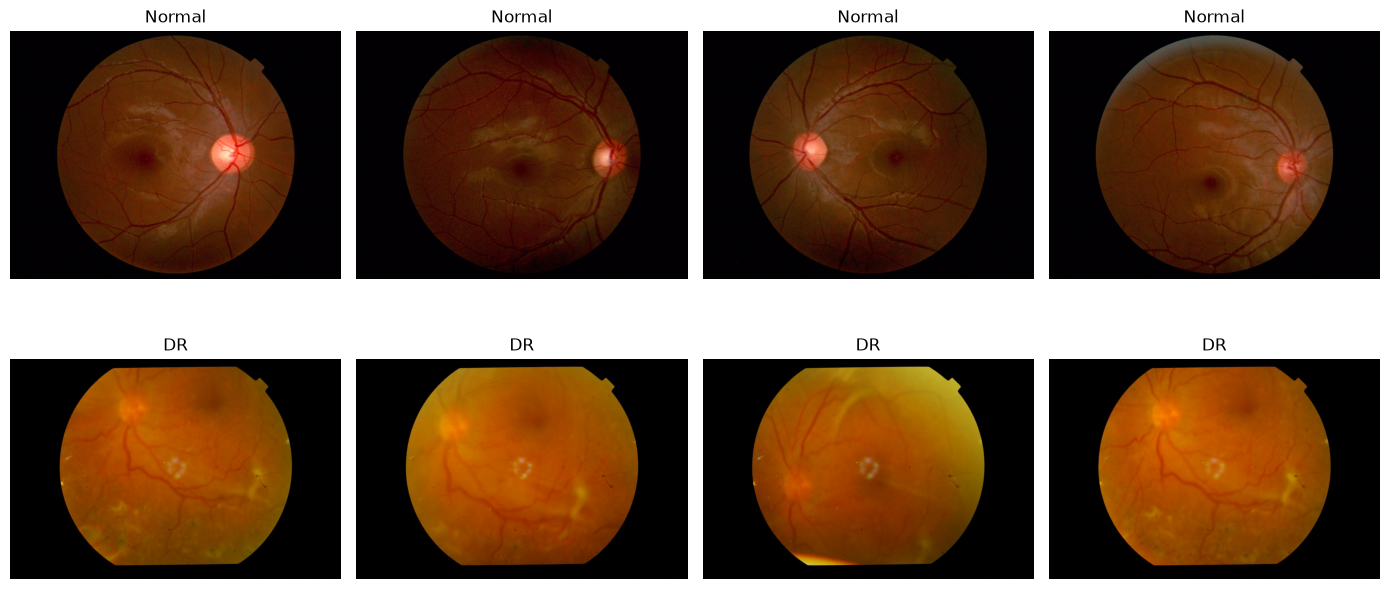

In [64]:
fig, axes = plt.subplots(2, 4, figsize=(14, 7))

for row, target in enumerate([0, 1]):

    samples = binary_only[
        binary_only["DR"] == target
    ].sample(4, random_state=42)

    for ax, (_, row_data) in zip(
        axes[row],
        samples.iterrows()
    ):
        img = Image.open(row_data["image_path"])

        ax.imshow(img)
        ax.set_title(
            "Normal" if target == 0 else "DR"
        )
        ax.axis("off")

plt.tight_layout()
plt.show()

In [65]:
import hashlib
from collections import defaultdict

def file_hash(path):
    h = hashlib.md5()
    with open(path, "rb") as f:
        h.update(f.read())
    return h.hexdigest()


all_images = {
    "train": train_images,
    "validation": [
        p for p in VAL_DIR.iterdir()
        if p.suffix.lower() in [".jpg", ".jpeg", ".png"]
    ],
    "test": [
        p for p in TEST_DIR.iterdir()
        if p.suffix.lower() in [".jpg", ".jpeg", ".png"]
    ]
}

hashes = defaultdict(list)

for split, images in all_images.items():
    for path in images:
        hashes[file_hash(path)].append((split, path.name))


duplicate_groups = {
    h: files
    for h, files in hashes.items()
    if len(files) > 1
}

print("Duplicate groups:", len(duplicate_groups))

for h, files in duplicate_groups.items():
    print("\nDuplicate group:")
    for split, filename in files:
        print(f"  {split}: {filename}")

Duplicate groups: 3

Duplicate group:
  train: 798.jpg
  test: 886.jpg

Duplicate group:
  validation: 799.jpg
  test: 887.jpg

Duplicate group:
  validation: 800.jpg
  test: 888.jpg


In [66]:
for split_name, split_dir in [
    ("Training", TRAIN_DIR),
    ("Validation", VAL_DIR),
    ("Test", TEST_DIR)
]:
    
    csv_file = list(split_dir.glob("*.csv"))[0]
    
    df = pd.read_csv(
        csv_file,
        encoding="latin1"
    )
    
    duplicate_ids = df[
        df["ID"].duplicated(keep=False)
    ]
    
    print(
        f"{split_name}: "
        f"{len(duplicate_ids)} rows with duplicated IDs"
    )

Training: 0 rows with duplicated IDs
Validation: 0 rows with duplicated IDs
Test: 0 rows with duplicated IDs


In [67]:
duplicate_ids = [
    ("798", "886"),
    ("799", "887"),
    ("800", "888")
]

for id1, id2 in duplicate_ids:
    print(f"\nDuplicate pair: {id1} ↔ {id2}")
    
    for split_name, split_dir in [
        ("Training", TRAIN_DIR),
        ("Validation", VAL_DIR),
        ("Test", TEST_DIR)
    ]:
        csv_file = list(split_dir.glob("*.csv"))[0]
        
        df = pd.read_csv(
            csv_file,
            encoding="latin1"
        )
        
        df.columns = df.columns.str.strip()
        df = df.loc[
            :,
            ~df.columns.str.startswith("Unnamed")
        ]
        
        rows = df[
            df["ID"].astype(str).isin([id1, id2])
        ]
        
        if len(rows) > 0:
            print(f"\n{split_name}:")
            print(rows[["ID", "WNL", "DR"]].to_string(index=False))


Duplicate pair: 798 ↔ 886

Training:
 ID  WNL  DR
798    1   0

Test:
 ID  WNL  DR
886    1   0

Duplicate pair: 799 ↔ 887

Validation:
 ID  WNL  DR
799    1   0

Test:
 ID  WNL  DR
887    1   0

Duplicate pair: 800 ↔ 888

Validation:
 ID  WNL  DR
800    1   0

Test:
 ID  WNL  DR
888    1   0


## Exploratory Data Analysis Summary

* **Dataset:** RFMiD 2.0 retinal fundus image dataset with multiple disease/finding annotations.

* **Binary classification definition:**

  * **DR:** `DR = 1`
  * **Normal:** `DR = 0` and `WNL = 1`
  * Images with `DR = 0` and `WNL = 0` were excluded because they may contain other retinal diseases or abnormalities.

* **Image-label matching:**

  * Training: **507 matched image-label pairs**
  * Validation: **177 matched image-label pairs**
  * Test: **170 matched image-label pairs**

* **Binary class distribution:**

  * Training: **42 DR / 156 Normal**
  * Validation: **14 DR / 53 Normal**
  * Test: **14 DR / 52 Normal** before duplicate removal.
  * The dataset is therefore **imbalanced**, with more Normal images than DR images.

* **Image resolutions:**

  * **512×512:** 313 images
  * **1504×1000:** 52 images
  * **2048×1536:** 144 images
  * The three resolutions represent different image dimensions/aspect ratios.

* **Resolution and class bias:**

  * All DR images in the binary subsets were **1504×1000**.
  * Normal images were mainly **2048×1536**, with some **512×512** images.
  * This creates a strong association between resolution and class and represents a potential **dataset bias / shortcut-learning risk**.
  * The original images will not be modified; preprocessing will standardize the model input dimensions.

* **Label correlation analysis:**

  * Most relationships between the disease/finding labels and `DR` were weak.
  * The label columns are annotations describing retinal conditions and will **not be used as input features** for the image classifier.

* **Duplicate-image analysis:**

  * **3 exact duplicate pairs** were found across dataset splits.
  * All duplicated images were Normal/WNL.
  * One duplicate occurred between **Training and Test**.
  * Two duplicates occurred between **Validation and Test**.
  * The duplicated test copies will be excluded from final evaluation to reduce potential data leakage.
  * The original RFMiD files will remain unchanged.

* **Visual inspection:**

  * Representative DR and Normal fundus images were visually inspected.
  * The images were confirmed to contain retinal fundus photographs suitable for the planned image-classification task.

* **Overall conclusion:**

  * The EDA established the class definitions, class imbalance, image characteristics, resolution bias, and duplicate-image issues.
  * These findings will be considered when designing the **preprocessing and EfficientNet-B0 training pipeline**.
